# Movie Recommendation System

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### 1. Load data

In [2]:
movies = pd.read_csv('../data/ml-latest-small/movies.csv')
ratings = pd.read_csv('../data/ml-latest-small/ratings.csv')
links = pd.read_csv('../data/ml-latest-small/links.csv')
tags = pd.read_csv('../data/ml-latest-small/tags.csv')

In [3]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [6]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


#### 2. Data analysis

In [7]:
n_ratings = len(ratings)
n_movies = movies['movieId'].nunique()
n_users = ratings['userId'].nunique()

print(f'Number of unique movies: {n_movies}')
print(f'Number of unique users: {n_users}')
print(f'Number of ratings: {n_ratings}')
print(f'Average number of ratings per movie: {round(n_ratings/n_movies, 2)}')
print(f'Average number of ratings per user: {round(n_ratings/n_users, 2)}')

Number of unique movies: 9742
Number of unique users: 610
Number of ratings: 100836
Average number of ratings per movie: 10.35
Average number of ratings per user: 165.3


We can see that our data is pretty dense, considering the fact that users rated 165 movies on average.\
Now let's check the distribution of ratings.

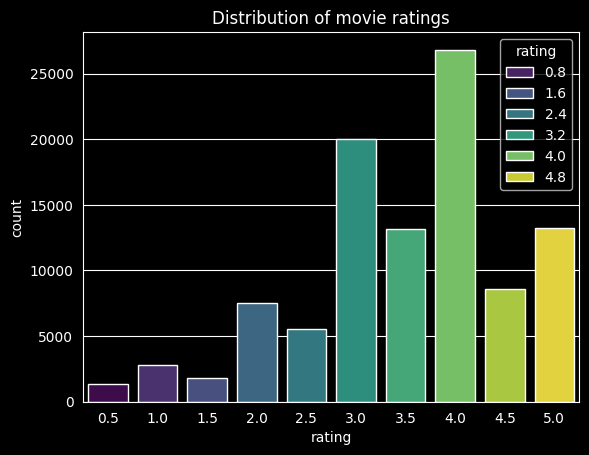

In [8]:
sns.countplot(x='rating', data=ratings, hue='rating', palette='viridis')
plt.title('Distribution of movie ratings')
plt.show()

We can see that our users are quite optimistic with their ratings, but that is normal and expected for this kind of data.

In [9]:
movie_ratings = ratings.merge(movies, on='movieId')
movie_ratings.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


Let's see which movies were rated the most.

In [10]:
movie_ratings['title'].value_counts()[0:5]

title
Forrest Gump (1994)                 329
Shawshank Redemption, The (1994)    317
Pulp Fiction (1994)                 307
Silence of the Lambs, The (1991)    279
Matrix, The (1999)                  278
Name: count, dtype: int64

The most popular movies were rated the most. This makes sense.\
Now let's find out which are the best and the worst rated movie in the dataset.

In [11]:
mean_ratings = ratings.groupby('movieId')[['rating']].mean()
mean_ratings.head()

,rating
movieId,
1,3.920930
2,3.431818
3,3.259615
4,2.357143
5,3.071429


In [12]:
lowest_rated = mean_ratings['rating'].idxmin()
movies[movies['movieId'] == lowest_rated]

,movieId,title,genres
2689,3604,Gypsy (1962),Musical


In [13]:
highest_rated = mean_ratings['rating'].idxmax()
movies[movies['movieId'] == highest_rated]

,movieId,title,genres
48,53,Lamerica (1994),Adventure|Drama


In [14]:
ratings[ratings['movieId'] == highest_rated]

,userId,movieId,rating,timestamp
13368,85,53,5.0,889468268
96115,603,53,5.0,963180003


_Lamerica_ has only two 5-star ratings so we should try another metrics, for example Bayesian average.

#### Bayesian average
is defined as

$r_i = \frac{C \times m + \sum \text{ratings}}{C + N}$

where $C$ represents confidence factor (the average number of ratings across all movies), $m$ represents the prior (the average mean rating across all movies) and $N$ is the total number of reviews for movie $i$.

After using Bayesian average, movies with fewer ratings will get "shrunk" toward the global average, while movies with many ratings will stay closer to their actual average.

In [15]:
movie_stats = ratings.groupby('movieId')['rating'].agg(['count', 'mean'])
movie_stats.head()

,count,mean
movieId,,
1,215,3.920930
2,110,3.431818
3,52,3.259615
4,7,2.357143
5,49,3.071429


In [16]:
C = movie_stats['count'].mean()
m = movie_stats['mean'].mean()

print(f'Average number of ratings per movie: {round(C, 2)}')
print(f'Average number of ratings per user: {round(m, 2)}')

Average number of ratings per movie: 10.37
Average number of ratings per user: 3.26


In [17]:
def bayesian_avg(ratings):
    calc = (C*m + ratings.sum())/(C + ratings.count())
    return round(calc, 2)

In [18]:
lamerica = ratings[ratings['movieId'] == highest_rated]['rating']
bayesian_avg(lamerica)

3.54

We can now see that _Lamerica_'s Bayesian average is $3.54$, which is more convincing.

In [19]:
bayesian_avgs = ratings.groupby('movieId')['rating'].agg(bayesian_avg).reset_index()
bayesian_avgs.columns = ['movieId', 'bayesian_avg']
bayesian_avgs.head()

,movieId,bayesian_avg
0,1,3.89
1,2,3.42
2,3,3.26
3,4,2.90
4,5,3.10


In [20]:
movie_stats = movie_stats.merge(bayesian_avgs, on='movieId')
movie_stats.head()

,movieId,count,mean,bayesian_avg
0,1,215,3.920930,3.89
1,2,110,3.431818,3.42
2,3,52,3.259615,3.26
3,4,7,2.357143,2.90
4,5,49,3.071429,3.10


In [21]:
movie_stats = movie_stats.merge(movies[['movieId', 'title']])
movie_stats.head()

,movieId,count,mean,bayesian_avg,title
0,1,215,3.920930,3.89,Toy Story (1995)
1,2,110,3.431818,3.42,Jumanji (1995)
2,3,52,3.259615,3.26,Grumpier Old Men (1995)
3,4,7,2.357143,2.90,Waiting to Exhale (1995)
4,5,49,3.071429,3.10,Father of the Bride Part II (1995)


In [22]:
movie_stats.sort_values(by='bayesian_avg', ascending=False)

,movieId,count,mean,bayesian_avg,title
277,318,317,4.429022,4.39,"Shawshank Redemption, The (1994)"
659,858,192,4.289062,4.24,"Godfather, The (1972)"
2224,2959,218,4.272936,4.23,Fight Club (1999)
921,1221,129,4.259690,4.19,"Godfather: Part II, The (1974)"
46,50,204,4.237745,4.19,"Usual Suspects, The (1995)"
...,...,...,...,...,...
1988,2643,16,1.687500,2.31,Superman IV: The Quest for Peace (1987)
1144,1499,27,1.925926,2.30,Anaconda (1997)
1372,1882,33,1.954545,2.27,Godzilla (1998)
2679,3593,19,1.657895,2.22,Battlefield Earth (2000)


We can now see that Bayesian average gives us a better sense of which movies are actually highly rated.

In [23]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [24]:
movies['genres'] = movies['genres'].apply(lambda x: x.split('|'))
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]"
1,2,Jumanji (1995),"[Adventure, Children, Fantasy]"
2,3,Grumpier Old Men (1995),"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),"[Comedy, Drama, Romance]"
4,5,Father of the Bride Part II (1995),[Comedy]


In [25]:
from collections import Counter

genre_frequency = Counter(g for genres in movies['genres'] for g in genres)
print(f'There are {len(genre_frequency)} genres in total.')
genre_frequency

There are 20 genres in total.


Counter({'Drama': 4361,
         'Comedy': 3756,
         'Thriller': 1894,
         'Action': 1828,
         'Romance': 1596,
         'Adventure': 1263,
         'Crime': 1199,
         'Sci-Fi': 980,
         'Horror': 978,
         'Fantasy': 779,
         'Children': 664,
         'Animation': 611,
         'Mystery': 573,
         'Documentary': 440,
         'War': 382,
         'Musical': 334,
         'Western': 167,
         'IMAX': 158,
         'Film-Noir': 87,
         '(no genres listed)': 34})

In [26]:
genre_frequency_df = pd.DataFrame([genre_frequency]).T.reset_index()
genre_frequency_df.columns = ['genre', 'count']
genre_frequency_df

,genre,count
0,Adventure,1263
1,Animation,611
2,Children,664
3,Comedy,3756
4,Fantasy,779
5,Romance,1596
6,Drama,4361
7,Action,1828
8,Crime,1199
9,Thriller,1894


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'Drama'),
  Text(1, 0, 'Comedy'),
  Text(2, 0, 'Thriller'),
  Text(3, 0, 'Action'),
  Text(4, 0, 'Romance'),
  Text(5, 0, 'Adventure'),
  Text(6, 0, 'Crime'),
  Text(7, 0, 'Sci-Fi'),
  Text(8, 0, 'Horror'),
  Text(9, 0, 'Fantasy'),
  Text(10, 0, 'Children'),
  Text(11, 0, 'Animation'),
  Text(12, 0, 'Mystery'),
  Text(13, 0, 'Documentary'),
  Text(14, 0, 'War'),
  Text(15, 0, 'Musical'),
  Text(16, 0, 'Western'),
  Text(17, 0, 'IMAX'),
  Text(18, 0, 'Film-Noir'),
  Text(19, 0, '(no genres listed)')])

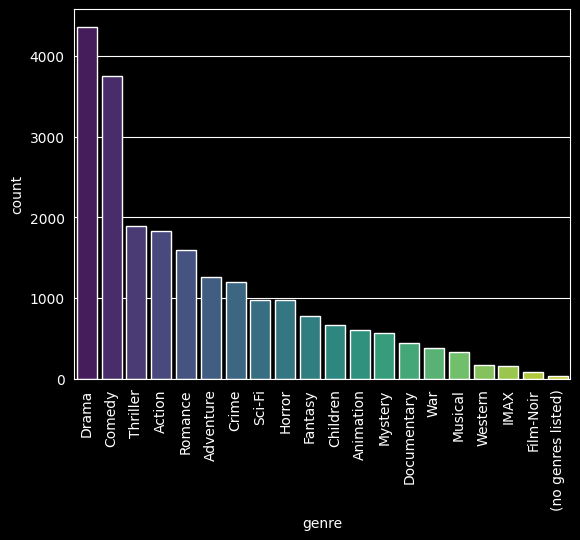

In [27]:
sns.barplot(x='genre', y='count', data=genre_frequency_df.sort_values(by='count', ascending=False), hue='genre', palette='viridis')
plt.xticks(rotation=90)